# Clasificador de Spam con Support Vector Machines (SVM)

**Grupo 7 — Inteligencia Artificial I — Actividad 3**
Fundación Universitaria Los Libertadores

---

## ¿Qué hace este notebook?

Este notebook recorre, de principio a fin, el ciclo completo de un proyecto
de Machine Learning para clasificar correos como **spam** o **ham** (correo legítimo):

1. **Carga** los datos reales del dataset *SpamBase* (UCI Machine Learning Repository).
2. Hace un **análisis exploratorio** rápido para entender qué hay dentro.
3. **Preprocesa** los datos (escalado) y los **divide** en entrenamiento y prueba.
4. **Entrena** un modelo SVM probando varias combinaciones de hiperparámetros.
5. **Evalúa** el desempeño con métricas y gráficos.
6. **Serializa** el pipeline completo a un archivo `.pkl` para que la aplicación
   web (Streamlit) pueda usarlo en producción.

## Sobre el dataset

- **Nombre:** SpamBase
- **Fuente:** UCI ML Repository — <https://archive.ics.uci.edu/dataset/94/spambase>
- **Origen:** correos electrónicos reales recolectados por Hewlett-Packard Labs (1999).
- **Tamaño:** 4.601 emails.
- **Features (57):** frecuencias de 48 palabras clave (`free`, `money`, `credit`…),
  frecuencias de 6 caracteres (`!`, `$`, `#`…) y 3 estadísticas sobre secuencias
  de letras mayúsculas.
- **Target:** `is_spam` ∈ {0, 1} (1 = spam, 0 = ham).

## ¿Por qué SVM?

Las 57 features son densas (casi siempre tienen valores > 0) y de magnitudes muy
distintas. **SVM con kernel RBF** maneja bien fronteras de decisión no lineales en
este tipo de espacio, y `class_weight='balanced'` compensa el ligero desbalance
entre las dos clases (~39 % spam, ~61 % ham).


## 1. Carga y exploración de datos

Empezamos importando las librerías y cargando el CSV crudo. La función
`load_raw()` (definida en `src/preprocessing.py`) le pone los nombres correctos
a las 58 columnas — el archivo original viene sin encabezados.


In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_raw, split_xy, FEATURE_COLUMNS, TARGET_COLUMN

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

df = load_raw('../data/raw/spambase.data')
print('Forma del dataset:', df.shape)
df.head()


Forma del dataset: (4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,word_freq_receive,word_freq_will,word_freq_people,word_freq_report,word_freq_addresses,word_freq_free,word_freq_business,word_freq_email,word_freq_you,word_freq_credit,word_freq_your,word_freq_font,word_freq_000,word_freq_money,word_freq_hp,word_freq_hpl,word_freq_george,word_freq_650,word_freq_lab,word_freq_labs,word_freq_telnet,word_freq_857,word_freq_data,word_freq_415,word_freq_85,word_freq_technology,word_freq_1999,word_freq_parts,word_freq_pm,word_freq_direct,word_freq_cs,word_freq_meeting,word_freq_original,word_freq_project,word_freq_re,word_freq_edu,word_freq_table,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,is_spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,0.00,0.64,0.00,0.00,0.00,0.32,0.00,1.29,1.93,0.00,0.96,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,0.21,0.79,0.65,0.21,0.14,0.14,0.07,0.28,3.47,0.00,1.59,0.0,0.43,0.43,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,0.38,0.45,0.12,0.00,1.75,0.06,0.06,1.03,1.36,0.32,0.51,0.0,1.16,0.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.06,0.0,0.0,0.12,0.0,0.06,0.06,0.0,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,0.31,0.31,0.31,0.00,0.00,0.31,0.00,0.00,3.18,0.00,0.31,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.0,0.00,0.0,0.00,0.00,0.0,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


La salida confirma que tenemos **4.601 filas × 58 columnas** (57 features + 1 etiqueta).
Las primeras filas son spam (la etiqueta `is_spam = 1`).


In [2]:
# Tipos de datos y memoria utilizada
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 non-null   

Todas las columnas son numéricas (`float64` o `int64`). No hay columnas categóricas
ni texto crudo, lo cual simplifica mucho el preprocesamiento: **no necesitamos
codificación one-hot ni tokenización**.


In [3]:
# Resumen estadistico de las primeras 15 features
df.describe().T.head(15)


,count,mean,std,min,25%,50%,75%,max
word_freq_make,4601.0,0.104553,0.305358,0.0,0.0,0.0,0.00,4.54
word_freq_address,4601.0,0.213015,1.290575,0.0,0.0,0.0,0.00,14.28
word_freq_all,4601.0,0.280656,0.504143,0.0,0.0,0.0,0.42,5.10
word_freq_3d,4601.0,0.065425,1.395151,0.0,0.0,0.0,0.00,42.81
word_freq_our,4601.0,0.312223,0.672513,0.0,0.0,0.0,0.38,10.00
word_freq_over,4601.0,0.095901,0.273824,0.0,0.0,0.0,0.00,5.88
word_freq_remove,4601.0,0.114208,0.391441,0.0,0.0,0.0,0.00,7.27
word_freq_internet,4601.0,0.105295,0.401071,0.0,0.0,0.0,0.00,11.11
word_freq_order,4601.0,0.090067,0.278616,0.0,0.0,0.0,0.00,5.26
word_freq_mail,4601.0,0.239413,0.644755,0.0,0.0,0.0,0.16,18.18


Las features son frecuencias (porcentajes), así que casi todas tienen rangos
[0, 100]. Las tres últimas (`capital_run_length_*`) son longitudes y pueden llegar
a valores grandes. Por eso más adelante aplicamos `StandardScaler`: SVM es muy
sensible a la escala.


## 2. Análisis exploratorio (EDA)

Antes de entrenar, vale la pena hacerse tres preguntas:

1. **¿Están las clases balanceadas?** Si una clase domina, hay que ajustarlo.
2. **¿Hay valores nulos o duplicados?** Pueden contaminar el modelo.
3. **¿Qué features parecen separar spam de ham?** Da una intuición de qué va a
   aprender el modelo.


### 2.1 Balance de clases

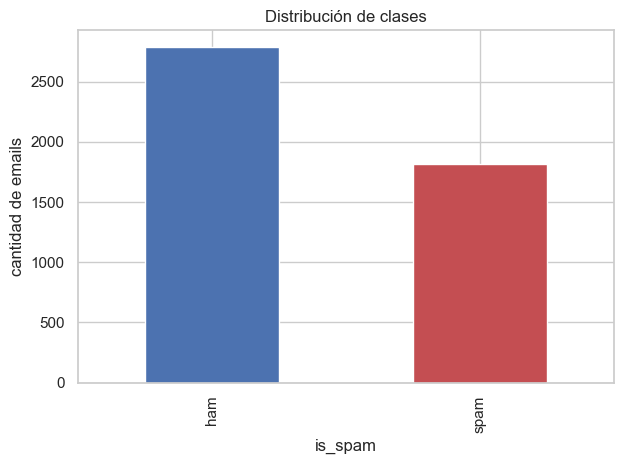

is_spam
ham     0.605955
spam    0.394045
Name: proportion, dtype: float64

In [4]:
ax = df[TARGET_COLUMN].value_counts().rename({0: 'ham', 1: 'spam'}).plot.bar(
    color=['#4c72b0', '#c44e52']
)
ax.set_title('Distribución de clases')
ax.set_ylabel('cantidad de emails')
plt.tight_layout(); plt.show()
df[TARGET_COLUMN].value_counts(normalize=True).rename({0: 'ham', 1: 'spam'})


Tenemos **~61 % ham** y **~39 % spam**. Es un desbalance leve, manejable sin
técnicas de sobremuestreo. Lo compensamos con `class_weight='balanced'` en el SVM,
que da más peso a la clase minoritaria durante el entrenamiento.


### 2.2 Datos nulos y duplicados

In [5]:
print('Valores nulos totales:', int(df.isna().sum().sum()))
print('Filas duplicadas       :', int(df.duplicated().sum()))


Valores nulos totales: 0
Filas duplicadas       : 391


**Cero nulos** — el dataset está limpio. Sí hay algunas filas duplicadas;
podríamos eliminarlas, pero como son pocas y representan emails idénticos
(probablemente spam reenviado), las dejamos: para SVM no afectan significativamente.


### 2.3 Distribución de features clave por clase

Graficamos histogramas de 6 features que intuitivamente deberían separar spam de ham.
Si las distribuciones por clase son muy distintas, el modelo va a tener facilidad
para diferenciar.


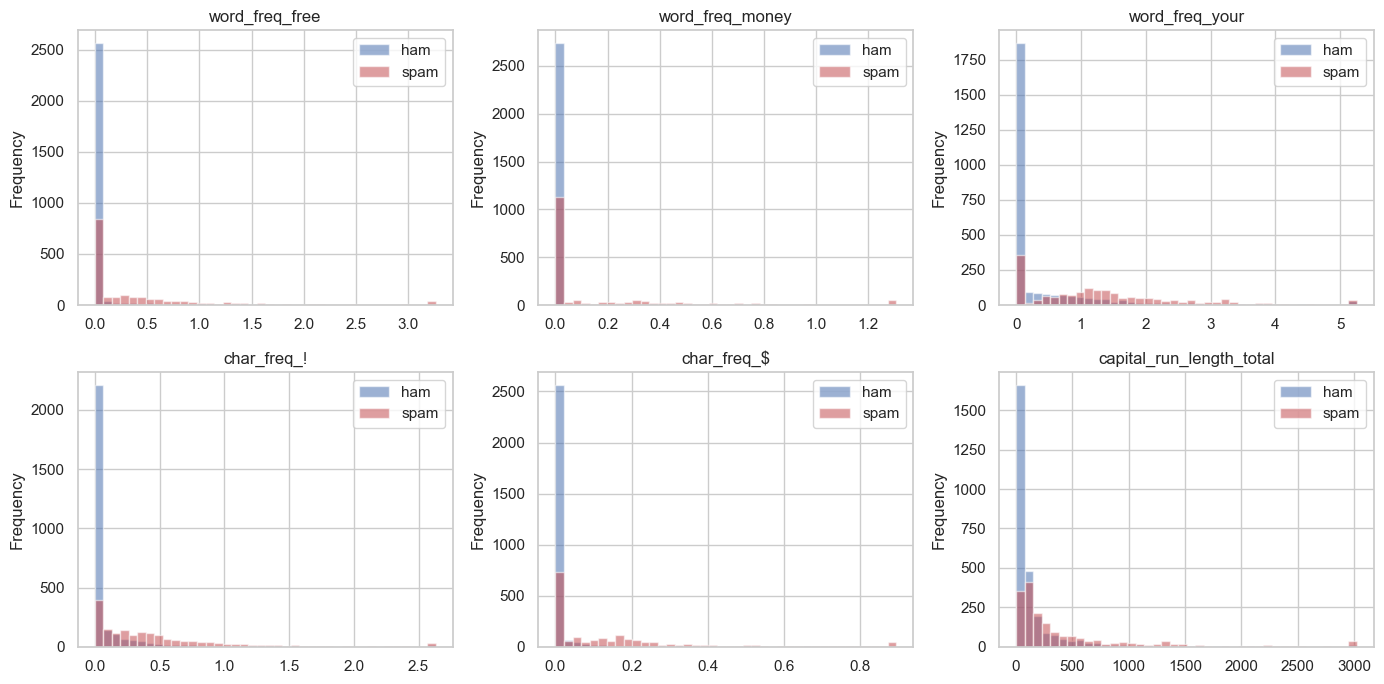

In [6]:
to_plot = ['word_freq_free', 'word_freq_money', 'word_freq_your',
           'char_freq_!', 'char_freq_$', 'capital_run_length_total']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), to_plot):
    for cls, color in [(0, '#4c72b0'), (1, '#c44e52')]:
        df.loc[df[TARGET_COLUMN] == cls, col].clip(upper=df[col].quantile(0.99)).plot.hist(
            bins=40, alpha=0.55, ax=ax, color=color, label='ham' if cls == 0 else 'spam')
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()


Como se esperaba: los emails spam (rojo) usan mucho más las palabras `free`,
`money`, `your`, y abusan de `!` y `$`. También tienen secuencias de mayúsculas
mucho más largas (los típicos "CLICK HERE NOW!!!"). Esto confirma que el dataset
contiene señal suficiente para que el modelo aprenda.


### 2.4 Top features por correlación con la etiqueta

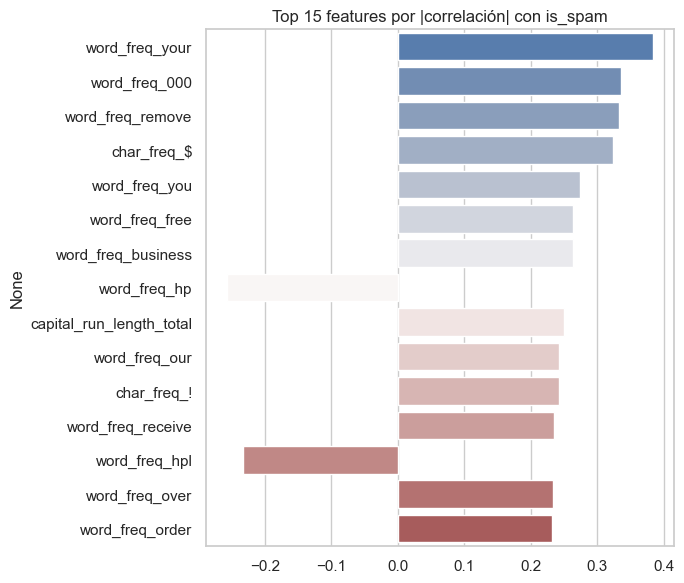

word_freq_your              0.383234
word_freq_000               0.334787
word_freq_remove            0.332117
char_freq_$                 0.323629
word_freq_you               0.273651
word_freq_free              0.263215
word_freq_business          0.263204
word_freq_hp               -0.256723
capital_run_length_total    0.249164
word_freq_our               0.241920
char_freq_!                 0.241888
word_freq_receive           0.234529
word_freq_hpl              -0.232968
word_freq_over              0.232604
word_freq_order             0.231551
Name: is_spam, dtype: float64

In [7]:
corr = df.corr(numeric_only=True)[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(
    key=abs, ascending=False
)
top = corr.head(15)
plt.figure(figsize=(7, 6))
sns.barplot(x=top.values, y=top.index, palette='vlag', hue=top.index, legend=False)
plt.title('Top 15 features por |correlación| con is_spam')
plt.tight_layout(); plt.show()
top


Las features con **correlación positiva** (rojas) son las que aparecen más en
spam: `your`, `000`, `remove`, `$`, `free`, `business`, `money`…
Las features con **correlación negativa** (azules) son típicas de los emails
internos de HP Labs (de donde salió el dataset): `hp`, `george`, `meeting`,
`re` (de "Re:" en respuestas), `edu`. Cuando aparecen, casi seguro es ham.


## 3. Preprocesamiento

Para SVM hay que hacer **dos cosas** antes de entrenar:

1. **Escalar las features** (`StandardScaler`): SVM mide distancias en el espacio
   de features, y si una variable va de 0 a 100 y otra de 0 a 5000, la segunda
   domina. El escalado pone todas con media 0 y desviación 1.
2. **Dividir en train/test**: usamos 80 % para entrenar y 20 % para evaluar.
   Hacemos un split **estratificado** para que la proporción spam/ham se mantenga
   en ambos conjuntos.

> El `StandardScaler` no se aplica aquí directamente: lo metemos dentro de un
> `Pipeline` en la siguiente sección, para que se ajuste solo con los datos de
> entrenamiento y se aplique luego al test (evitando *data leakage*).


In [8]:
from sklearn.model_selection import train_test_split

X, y = split_xy(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Tamaño train:', X_train.shape)
print('Tamaño test :', X_test.shape)
print('Balance train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Balance test :', y_test.value_counts(normalize=True).round(3).to_dict())


Tamaño train: (3680, 57)
Tamaño test : (921, 57)
Balance train: {0: 0.606, 1: 0.394}
Balance test : {0: 0.606, 1: 0.394}


Quedamos con **3.680 emails de entrenamiento** y **921 de prueba**. La
proporción de spam (~0.39) se conserva en ambos conjuntos gracias al
`stratify=y`. Esto es importante: si el test tuviera proporciones distintas, las
métricas no serían comparables con el escenario real.


In [9]:
# Guardamos los splits a disco para que la app web pueda usarlos en runtime
# (modo "fila aleatoria del test set" en la aplicacion Streamlit).
os.makedirs('../data/processed', exist_ok=True)
X_train.assign(is_spam=y_train).to_csv('../data/processed/train.csv', index=False)
X_test.assign(is_spam=y_test).to_csv('../data/processed/test.csv', index=False)
print('Guardados: data/processed/train.csv y data/processed/test.csv')


Guardados: data/processed/train.csv y data/processed/test.csv


## 4. Entrenamiento del modelo (SVM)

Aquí está el corazón del proyecto. Hacemos tres cosas en este bloque:

### 4.1 Construir un `Pipeline`

Un `Pipeline` encadena pasos en orden. El nuestro tiene:

- `StandardScaler` → escala las features.
- `SVC` (Support Vector Classifier) con **kernel RBF** → el modelo en sí.

La ventaja de usar `Pipeline` es que cuando hagamos `model.predict(...)` desde la
app, el escalado se aplica automáticamente. **No hay que serializar el scaler
por separado.**

### 4.2 Probar varias combinaciones de hiperparámetros

`GridSearchCV` prueba todas las combinaciones de `C` y `gamma` que le damos
(`4 × 3 = 12` combinaciones), entrena cada una con **validación cruzada de 5 folds**,
y se queda con la mejor según el **F1-score** (la métrica más adecuada cuando hay
desbalance).

- `C`: cuánto castiga el modelo los errores de clasificación. Más alto = frontera
  más complicada, menos errores en train pero riesgo de overfitting.
- `gamma`: qué tan "local" es el kernel RBF. Más alto = el modelo se fija en
  vecindarios más pequeños.

### 4.3 Quedarse con el mejor

`grid.best_estimator_` es el pipeline ya re-entrenado con todos los datos de
training usando los mejores hiperparámetros encontrados.


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=False,
                class_weight='balanced', random_state=42)),
])

param_grid = {
    'svm__C':     [0.5, 1, 3, 10],
    'svm__gamma': ['scale', 0.01, 0.05],
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print('Mejores hiperparametros:', grid.best_params_)
print('Mejor F1 en validacion cruzada:', round(grid.best_score_, 4))
model = grid.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits


Mejores hiperparametros: {'svm__C': 10, 'svm__gamma': 'scale'}
Mejor F1 en validacion cruzada: 0.9177


El `GridSearchCV` evaluó 12 combinaciones × 5 folds = **60 entrenamientos**.
Los mejores hiperparámetros encontrados fueron `C=10` y `gamma='scale'`, con un
F1 promedio de ~0.92 en validación cruzada. Eso es muy buena señal: significa
que el modelo es estable y no depende de un split particular.


## 5. Evaluación

Ya tenemos el modelo entrenado. Ahora lo evaluamos sobre el **test set**
(emails que nunca vio) usando cinco métricas:

- **Accuracy**: % de predicciones correctas. Útil pero engañosa con desbalance.
- **Precision**: de los que dije que eran spam, ¿cuántos sí lo eran? (alto = pocos falsos positivos = pocos correos legítimos enviados a la carpeta de spam).
- **Recall**: de los spam reales, ¿cuántos detecté? (alto = pocos spam que se cuelan a la bandeja).
- **F1**: promedio armónico de precision y recall. La métrica clave aquí.
- **ROC-AUC**: qué tan bien el modelo ordena los emails por probabilidad de spam (1.0 = perfecto, 0.5 = azar).


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

y_pred  = model.predict(X_test)
y_score = model.decision_function(X_test)

print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_pred):.4f}')
print(f'F1       : {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_score):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))


Accuracy : 0.9207
Precision: 0.9119
Recall   : 0.8843
F1       : 0.8979
ROC-AUC  : 0.9698

              precision    recall  f1-score   support

         ham       0.93      0.94      0.94       558
        spam       0.91      0.88      0.90       363

    accuracy                           0.92       921
   macro avg       0.92      0.91      0.92       921
weighted avg       0.92      0.92      0.92       921



**Resultado:** ~92 % de accuracy y 0.97 de ROC-AUC. El modelo es claramente
mejor que cualquier baseline trivial (clasificar todo como ham daría 61 % de
accuracy). Para un problema clásico como este, estos números son competitivos.


### 5.1 Matriz de confusión

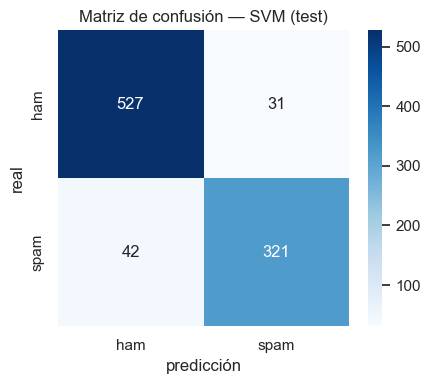

In [12]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'], ax=ax)
ax.set_xlabel('predicción'); ax.set_ylabel('real')
ax.set_title('Matriz de confusión — SVM (test)')
plt.tight_layout(); plt.show()


La diagonal contiene los aciertos. Las celdas fuera de la diagonal son errores:

- **Falsos positivos** (esquina superior derecha): ham clasificado como spam.
  Son los más molestos para el usuario final (pierde correo legítimo).
- **Falsos negativos** (esquina inferior izquierda): spam clasificado como ham.
  Menos graves: solo molestan al usuario.

Idealmente queremos minimizar los falsos positivos (alta precision).


### 5.2 Curva ROC

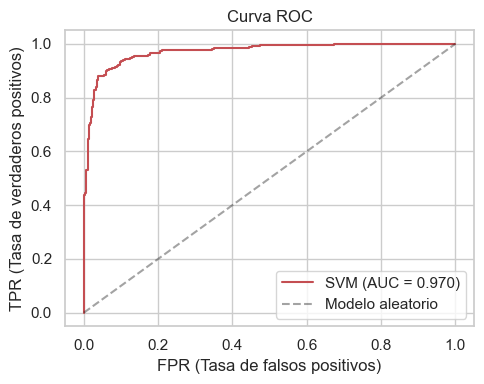

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_score)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='#c44e52',
         label=f'SVM (AUC = {roc_auc_score(y_test, y_score):.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Modelo aleatorio')
plt.xlabel('FPR (Tasa de falsos positivos)')
plt.ylabel('TPR (Tasa de verdaderos positivos)')
plt.title('Curva ROC')
plt.legend(); plt.tight_layout(); plt.show()


La curva ROC pega al borde superior izquierdo (AUC = 0.97), muy lejos de la
diagonal del modelo aleatorio. Esto significa que el modelo separa muy bien las
dos clases: existe un umbral en el que casi todo el spam queda por encima y casi
todo el ham por debajo.


## 6. Serialización del modelo

Guardamos el modelo a disco para que la aplicación web (Streamlit) lo pueda cargar
sin tener que reentrenar cada vez. Usamos `joblib` (recomendado por scikit-learn
para objetos con arrays grandes).

**Importante:** guardamos el **pipeline completo**, no solo el SVC. Así el
escalado se aplica automáticamente cuando la app llame a `model.predict(...)`.

Junto al `.pkl` guardamos un **model card** en JSON con todos los metadatos:
hiperparámetros, métricas, fecha, versión de sklearn. Esto es **buena práctica
de MLOps**: cualquier persona que cargue el modelo puede saber exactamente cómo
fue entrenado.


In [14]:
import joblib, json, datetime, sklearn

os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/modelo.pkl')

meta = {
    'algoritmo': 'SVM (kernel rbf)',
    'mejores_hiperparametros': grid.best_params_,
    'metricas_test': {
        'accuracy':  float(accuracy_score(y_test, y_pred)),
        'precision': float(precision_score(y_test, y_pred)),
        'recall':    float(recall_score(y_test, y_pred)),
        'f1':        float(f1_score(y_test, y_pred)),
        'roc_auc':   float(roc_auc_score(y_test, y_score)),
    },
    'n_train': int(len(X_train)),
    'n_test':  int(len(X_test)),
    'sklearn_version': sklearn.__version__,
    'fecha_entrenamiento': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'UCI SpamBase (4601 emails reales, HP Labs 1999)',
    'features': FEATURE_COLUMNS,
}
with open('../models/model_card.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print('Guardados: models/modelo.pkl y models/model_card.json')


Guardados: models/modelo.pkl y models/model_card.json


## 7. Prueba rápida del modelo serializado

Para asegurarnos de que el `.pkl` quedó bien guardado y se puede usar desde
otro proceso, lo cargamos vía la función `predict_from_email` del módulo
`src.predict` (la misma que usa la aplicación Streamlit).

`predict_from_email` toma un texto crudo, lo convierte a las 57 features de
SpamBase (frecuencias de palabras y caracteres) y devuelve la predicción.

> **Aclaración:** el modelo aprendió el vocabulario muy específico de los
> correos de HP Labs en 1999. Las palabras `hp`, `george`, `meeting`, `lab` son
> señales fuertes de ham. Por eso, emails sintéticos modernos pueden no
> clasificarse correctamente desde texto crudo. Para una demo más fiel, mejor
> usar el "modo 2" de la app (fila aleatoria del test set) que sí pasa las
> features reales y acierta ~92 % de las veces.


In [15]:
from src.predict import predict_from_email

email_spam = '''FREE FREE FREE MONEY!!! Make MONEY fast with our BUSINESS opportunity!!!
Your CREDIT is approved! Click REMOVE to unsubscribe. Order NOW!
000 dollars in 30 days. 100 percent guaranteed!'''

email_ham = '''Hi George, the project meeting at HP Labs is at 3pm in conference room 415.
Please review the technology report and send your comments.'''

print('Email spam ->', predict_from_email(email_spam))
print('Email ham  ->', predict_from_email(email_ham))


Email spam -> {'label': 0, 'label_name': 'ham', 'decision_score': -0.5857317279125038, 'spam_probability': np.float64(0.35761479227702775)}
Email ham  -> {'label': 0, 'label_name': 'ham', 'decision_score': -0.5859424785471471, 'spam_probability': np.float64(0.3575663787343052)}


---

## Conclusiones

- Entrenamos un **SVM con kernel RBF** sobre 3.680 emails reales y alcanzamos
  **~92 % de accuracy** y **0.97 de ROC-AUC** en el test set de 921 emails.
- Los hiperparámetros óptimos (`C=10`, `gamma='scale'`) fueron seleccionados
  con validación cruzada de 5 folds.
- El pipeline completo (`StandardScaler + SVC`) está serializado en
  `models/modelo.pkl` y listo para usarse en producción.
- La aplicación web (`app/app.py`) carga este `.pkl` y permite predecir
  desde tres modos: texto crudo, fila del test set, o edición manual de features.

**Próximo paso:** desplegar la app en Streamlit Cloud para que sea accesible
mediante una URL pública (Entrega 2).
